# Scenario forecasting, fan chart và Prophet benchmark

Notebook này bổ sung phần dự báo theo hướng **thực dụng và dễ trình bày trong báo cáo**:

1. Backtest mô hình forecast trên **annual official GDP growth**.
2. Tạo **3 kịch bản**:
   - baseline
   - hawkish / lãi suất cao hơn
   - dovish / lãi suất thấp hơn
3. Vẽ **scenario chart** và **fan chart**.
4. Nếu máy bạn có `prophet`, notebook sẽ chạy thêm **benchmark Prophet** như một phụ lục.


In [3]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, Markdown

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    PROPHET_AVAILABLE = False

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("secondary_data_annual.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Không tìm thấy secondary_data_annual.csv")

df = pd.read_csv(DATA_PATH)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df = df.sort_values("Year").reset_index(drop=True)

TARGET = "GDP_Growth"
EXOG = ["Inflation", "Interest_Rate"]

data = df[["Year", TARGET] + EXOG].dropna().copy()
display(data.tail())
display(Markdown(f"**Prophet available:** `{PROPHET_AVAILABLE}`"))


,Year,GDP_Growth,Inflation,Interest_Rate
24,2019,7.359,2.796,7.708
25,2020,2.865,3.221,7.648
26,2021,2.554,1.835,7.811
27,2022,8.538,3.157,8.013
28,2023,5.065,3.253,9.323


**Prophet available:** `False`

## 1. Hàm backtest expanding-window


In [4]:

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def fit_sarimax(train_df, order, target_col, exog_cols=None):
    y_train = train_df[target_col]
    exog_train = train_df[exog_cols] if exog_cols else None
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)

def expanding_backtest(frame, target_col, exog_cols=None, order=(1, 0, 0), min_train=15):
    preds = []
    actuals = []
    years = []

    for i in range(min_train, len(frame)):
        train = frame.iloc[:i].copy()
        test = frame.iloc[i:i+1].copy()

        try:
            res = fit_sarimax(train, order=order, target_col=target_col, exog_cols=exog_cols)
            exog_test = test[exog_cols] if exog_cols else None
            pred = res.get_forecast(steps=1, exog=exog_test).predicted_mean.iloc[0]

            preds.append(float(pred))
            actuals.append(float(test[target_col].iloc[0]))
            years.append(int(test["Year"].iloc[0]))
        except Exception:
            continue

    out = pd.DataFrame({
        "Year": years,
        "actual": actuals,
        "pred": preds,
    })
    if out.empty:
        return out, None

    metrics = {
        "RMSE": float(np.sqrt(mean_squared_error(out["actual"], out["pred"]))),
        "MAE": float(mean_absolute_error(out["actual"], out["pred"])),
        "MAPE": float(safe_mape(out["actual"], out["pred"])),
    }
    return out, metrics


## 2. So sánh một số đặc tả ARIMA/SARIMAX


In [5]:

candidate_orders = [(1, 0, 0), (2, 0, 0), (1, 1, 0), (0, 1, 1)]
model_rows = []
backtest_store = {}

for order in candidate_orders:
    bt_uni, m_uni = expanding_backtest(data, TARGET, exog_cols=None, order=order, min_train=15)
    if m_uni is not None:
        model_rows.append({
            "model": f"ARIMA{order}",
            "order": str(order),
            "uses_exog": False,
            **m_uni,
        })
        backtest_store[f"ARIMA{order}"] = bt_uni

    bt_exog, m_exog = expanding_backtest(data, TARGET, exog_cols=EXOG, order=order, min_train=15)
    if m_exog is not None:
        model_rows.append({
            "model": f"SARIMAX{order}",
            "order": str(order),
            "uses_exog": True,
            **m_exog,
        })
        backtest_store[f"SARIMAX{order}"] = bt_exog

model_compare = pd.DataFrame(model_rows).sort_values("RMSE")
model_compare.to_csv(OUTPUT_DIR / "04_forecast_model_compare.csv", index=False)
display(model_compare)


/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/TranAnh/Documents

,model,order,uses_exog,RMSE,MAE,MAPE
0,"ARIMA(1, 0, 0)","(1, 0, 0)",False,1.960409,1.336372,30.860827
1,"SARIMAX(1, 0, 0)","(1, 0, 0)",True,2.031378,1.374990,32.040239
2,"ARIMA(2, 0, 0)","(2, 0, 0)",False,2.136506,1.413835,32.096344
3,"SARIMAX(2, 0, 0)","(2, 0, 0)",True,2.241614,1.405472,33.017878
4,"ARIMA(1, 1, 0)","(1, 1, 0)",False,2.430523,1.474597,29.916461
5,"SARIMAX(1, 1, 0)","(1, 1, 0)",True,2.487547,1.552463,30.835728
7,"SARIMAX(0, 1, 1)","(0, 1, 1)",True,2.801331,1.719001,35.453302
6,"ARIMA(0, 1, 1)","(0, 1, 1)",False,2.983380,1.910903,43.215852


## 3. Prophet benchmark (optional)

Block này chỉ chạy nếu máy bạn đã có `prophet`.


In [6]:

prophet_metrics = None

if PROPHET_AVAILABLE:
    prophet_df = data.copy()
    prophet_df["ds"] = pd.to_datetime(prophet_df["Year"].astype(str) + "-12-31")
    prophet_df["y"] = prophet_df[TARGET]

    preds, actuals, years = [], [], []
    min_train = 15
    for i in range(min_train, len(prophet_df)):
        train = prophet_df.iloc[:i].copy()
        test = prophet_df.iloc[i:i+1].copy()

        try:
            m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
            for col in EXOG:
                m.add_regressor(col)
            m.fit(train[["ds", "y"] + EXOG])

            future = test[["ds"] + EXOG].copy()
            fc = m.predict(future)
            pred = float(fc["yhat"].iloc[0])

            preds.append(pred)
            actuals.append(float(test["y"].iloc[0]))
            years.append(int(test["Year"].iloc[0]))
        except Exception:
            continue

    prophet_bt = pd.DataFrame({"Year": years, "actual": actuals, "pred": preds})
    if not prophet_bt.empty:
        prophet_metrics = {
            "model": "Prophet + regressors",
            "order": "NA",
            "uses_exog": True,
            "RMSE": float(np.sqrt(mean_squared_error(prophet_bt["actual"], prophet_bt["pred"]))),
            "MAE": float(mean_absolute_error(prophet_bt["actual"], prophet_bt["pred"])),
            "MAPE": float(safe_mape(prophet_bt["actual"], prophet_bt["pred"])),
        }
        display(pd.DataFrame([prophet_metrics]))
        prophet_bt.to_csv(OUTPUT_DIR / "04_prophet_backtest.csv", index=False)
    else:
        print("Prophet có cài nhưng không tạo được backtest hợp lệ.")
else:
    print("Chưa cài prophet. Nếu cần benchmark này, chạy: pip install prophet")


Chưa cài prophet. Nếu cần benchmark này, chạy: pip install prophet


## 4. Chọn mô hình chính và fit full sample


In [7]:

if model_compare.empty:
    raise RuntimeError("Không có mô hình nào fit được trong block backtest.")

best_row = model_compare.iloc[0]
BEST_MODEL_NAME = best_row["model"]
BEST_ORDER = tuple(int(x.strip()) for x in best_row["order"].strip("()").split(","))
BEST_USES_EXOG = bool(best_row["uses_exog"])

display(Markdown(
    f"**Mô hình tốt nhất theo RMSE hiện tại:** `{BEST_MODEL_NAME}` với order = `{BEST_ORDER}`."
))

best_res = fit_sarimax(
    data,
    order=BEST_ORDER,
    target_col=TARGET,
    exog_cols=EXOG if BEST_USES_EXOG else None,
)


**Mô hình tốt nhất theo RMSE hiện tại:** `ARIMA(1, 0, 0)` với order = `(1, 0, 0)`.

/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 5. Tạo kịch bản dự báo

Bạn chỉ cần sửa bảng `scenario_inputs` dưới đây nếu muốn giả định khác.


In [8]:

last_year = int(data["Year"].iloc[-1])
future_years = [last_year + 1, last_year + 2, last_year + 3]

infl_base = float(data["Inflation"].tail(3).mean())
rate_base = float(data["Interest_Rate"].tail(3).mean())

scenario_inputs = pd.DataFrame({
    "Year": future_years,
    "Inflation_baseline": [infl_base, infl_base, infl_base],
    "Interest_Rate_baseline": [rate_base, rate_base, rate_base],

    "Inflation_hawkish": [infl_base + 0.5, infl_base + 0.6, infl_base + 0.7],
    "Interest_Rate_hawkish": [rate_base + 1.0, rate_base + 1.0, rate_base + 1.0],

    "Inflation_dovish": [max(infl_base - 0.5, 0), max(infl_base - 0.6, 0), max(infl_base - 0.7, 0)],
    "Interest_Rate_dovish": [max(rate_base - 1.0, 0), max(rate_base - 1.0, 0), max(rate_base - 1.0, 0)],
})

display(scenario_inputs)


,Year,Inflation_baseline,Interest_Rate_baseline,Inflation_hawkish,Interest_Rate_hawkish,Inflation_dovish,Interest_Rate_dovish
0,2024,2.748333,8.382333,3.248333,9.382333,2.248333,7.382333
1,2025,2.748333,8.382333,3.348333,9.382333,2.148333,7.382333
2,2026,2.748333,8.382333,3.448333,9.382333,2.048333,7.382333


In [9]:

def forecast_under_scenario(result, scenario_df, uses_exog=True):
    output_rows = []
    for scenario_name in ["baseline", "hawkish", "dovish"]:
        if uses_exog:
            exog_future = scenario_df[[f"Inflation_{scenario_name}", f"Interest_Rate_{scenario_name}"]].copy()
            exog_future.columns = EXOG
            fc = result.get_forecast(steps=len(scenario_df), exog=exog_future)
        else:
            fc = result.get_forecast(steps=len(scenario_df))

        pred = fc.predicted_mean
        ci = fc.conf_int(alpha=0.20)  # khoảng 80%
        tmp = pd.DataFrame({
            "Year": scenario_df["Year"].values,
            "scenario": scenario_name,
            "forecast": pred.values,
            "lower80": ci.iloc[:, 0].values,
            "upper80": ci.iloc[:, 1].values,
        })
        output_rows.append(tmp)

    return pd.concat(output_rows, ignore_index=True)

scenario_forecast = forecast_under_scenario(best_res, scenario_inputs, uses_exog=BEST_USES_EXOG)
scenario_forecast.to_csv(OUTPUT_DIR / "04_scenario_forecast.csv", index=False)
display(scenario_forecast)


/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/TranAnh/Documents/Data_file_NCKH/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Year,scenario,forecast,lower80,upper80
0,2024,baseline,6.061598,4.359269,7.763928
1,2025,baseline,6.228169,4.502226,7.954112
2,2026,baseline,6.256009,4.529411,7.982607
3,2024,hawkish,6.061598,4.359269,7.763928
4,2025,hawkish,6.228169,4.502226,7.954112
5,2026,hawkish,6.256009,4.529411,7.982607
6,2024,dovish,6.061598,4.359269,7.763928
7,2025,dovish,6.228169,4.502226,7.954112
8,2026,dovish,6.256009,4.529411,7.982607


## 6. Scenario chart và fan chart


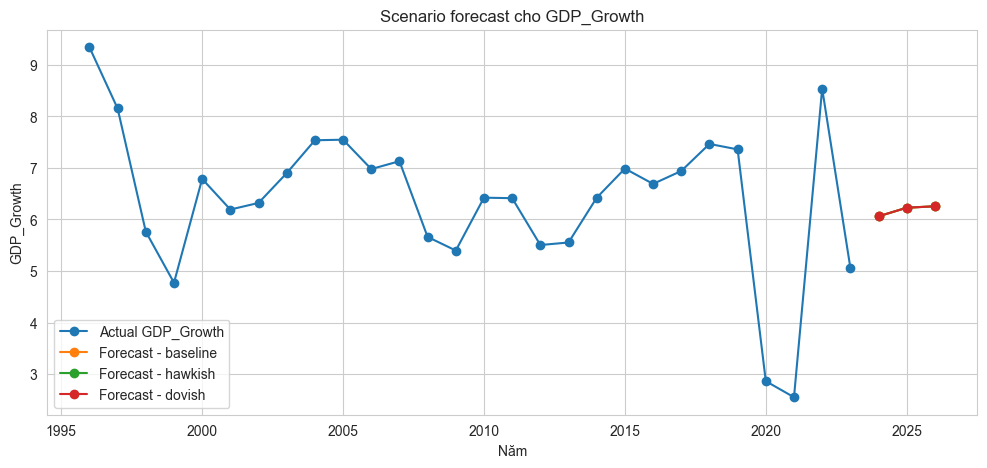

In [10]:

plt.figure(figsize=(12, 5))
plt.plot(data["Year"], data[TARGET], marker="o", label="Actual GDP_Growth")

for scenario_name in ["baseline", "hawkish", "dovish"]:
    tmp = scenario_forecast[scenario_forecast["scenario"] == scenario_name]
    plt.plot(tmp["Year"], tmp["forecast"], marker="o", label=f"Forecast - {scenario_name}")

plt.title("Scenario forecast cho GDP_Growth")
plt.xlabel("Năm")
plt.ylabel("GDP_Growth")
plt.legend()
plt.show()


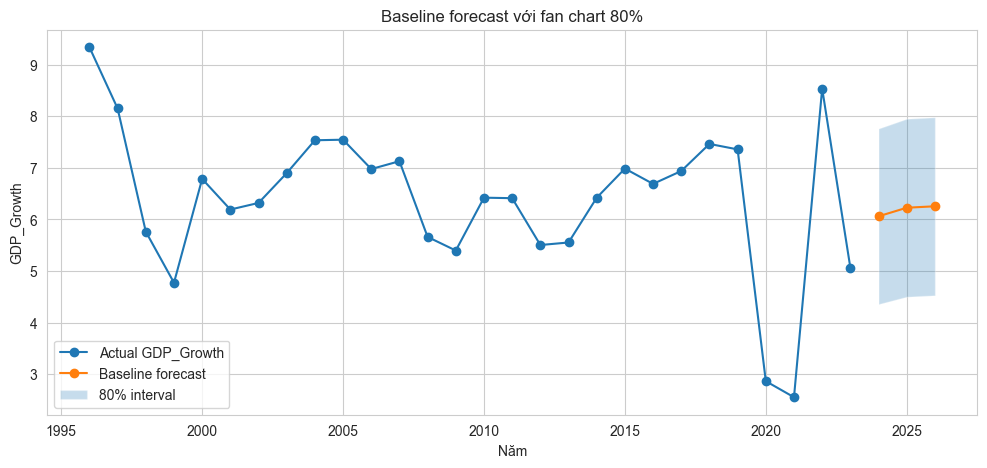

In [11]:

base_fc = scenario_forecast[scenario_forecast["scenario"] == "baseline"].copy()

plt.figure(figsize=(12, 5))
plt.plot(data["Year"], data[TARGET], marker="o", label="Actual GDP_Growth")
plt.plot(base_fc["Year"], base_fc["forecast"], marker="o", label="Baseline forecast")
plt.fill_between(base_fc["Year"], base_fc["lower80"], base_fc["upper80"], alpha=0.25, label="80% interval")
plt.title("Baseline forecast với fan chart 80%")
plt.xlabel("Năm")
plt.ylabel("GDP_Growth")
plt.legend()
plt.show()


## 7. Câu kết luận có thể dán vào báo cáo


In [12]:

summary_lines = [
    "### Kết luận gợi ý cho phần forecast theo kịch bản",
    f"- Mô hình chính được chọn theo RMSE expanding-window: `{BEST_MODEL_NAME}`.",
]

best_rmse = float(best_row["RMSE"])
summary_lines.append(f"- RMSE ngoài mẫu của mô hình chính = {best_rmse:.4f}.")

if prophet_metrics is not None:
    summary_lines.append(
        f"- Benchmark Prophet cho RMSE = {prophet_metrics['RMSE']:.4f}; "
        "bạn có thể để nó ở phụ lục như một benchmark breadth check."
    )
else:
    summary_lines.append("- Prophet benchmark là optional; notebook sẽ bỏ qua nếu máy chưa cài gói `prophet`.")

summary_lines.append(
    "- Bảng kịch bản baseline / hawkish / dovish rất phù hợp để chuyển sang phần policy implication hoặc slide bảo vệ."
)

summary_text = "\n".join(summary_lines)
display(Markdown(summary_text))

with open(OUTPUT_DIR / "04_forecast_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)


### Kết luận gợi ý cho phần forecast theo kịch bản
- Mô hình chính được chọn theo RMSE expanding-window: `ARIMA(1, 0, 0)`.
- RMSE ngoài mẫu của mô hình chính = 1.9604.
- Prophet benchmark là optional; notebook sẽ bỏ qua nếu máy chưa cài gói `prophet`.
- Bảng kịch bản baseline / hawkish / dovish rất phù hợp để chuyển sang phần policy implication hoặc slide bảo vệ.